# Classification sur le réseau mondial des lignes aériennes


Tâches : **T1** = prédire le pays (classification), **T2** = prédire `log10(population)` (régression).

In [1]:
import html
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.nn import LabelPropagation, Node2Vec
from torch_geometric.utils import to_undirected

warnings.filterwarnings("ignore")

RAW_PATH = Path("data/airportsAndCoordAndPop.graphml")
PROCESSED_DIR = Path("data/processed")
FIG_DIR = Path("results/figures")
RESULTS_DIR = Path("results")
for d in (PROCESSED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

MIN_CITIES = 5          # pays avec moins de villes -> OTHER
FILLER_POP = 10_000     # valeur de remplissage pour « population inconnue »
OTHER = "OTHER"

C:\Users\Busin\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Exploration du dataset

Nœud = ville desservie par un aéroport ; arête = ligne aérienne directe (non orientée, sans poids).
Attributs : `lat`, `lon`, `population`, `country` (cible T1), `city_name` (non utilisé).

In [2]:
def load_graph(path=RAW_PATH):
    """Graphe NetworkX avec des nœuds renumérotés 0..N-1 (ordre des ids GraphML)."""
    G = nx.read_graphml(path)
    return nx.relabel_nodes(G, {n: i for i, n in enumerate(sorted(G.nodes, key=int))})

G = load_graph()
N = G.number_of_nodes()
attrs = [G.nodes[i] for i in range(N)]
raw = pd.DataFrame(attrs)
raw["degree"] = [G.degree(i) for i in range(N)]
raw.head()

,lon,lat,population,country,city_name,degree
0,-145.509722,-17.353889,10000,FRENCH_POLYNESIA,Anaa,2
1,-140.950000,-18.066667,10000,FRENCH_POLYNESIA,Hao Island,4
2,-149.600000,-17.550000,26357,FRENCH_POLYNESIA,Papeete,27
3,-135.000000,-23.033333,10000,FRENCH_POLYNESIA,Gambier Island,2
4,-143.657250,-16.584889,10000,FRENCH_POLYNESIA,Makemo,2


In [3]:
comps = sorted(nx.connected_components(G), key=len, reverse=True)
deg = raw["degree"]
country_counts = raw["country"].value_counts()
same_country = np.mean([attrs[u]["country"] == attrs[v]["country"] for u, v in G.edges])
known = raw["population"] != FILLER_POP

stats = {
    "Nombre de nœuds": N,
    "Nombre d'arêtes": G.number_of_edges(),
    "Composantes connexes": f"{len(comps)} (géante : {len(comps[0])} nœuds)",
    "Degré moyen / médian / max": f"{deg.mean():.2f} / {deg.median():.0f} / {deg.max()}",
    "Plus gros hubs": ", ".join(f"{r.city_name} ({r.degree})"
                                 for r in raw.nlargest(5, "degree").itertuples()),
    "Nombre de pays (bruts)": raw["country"].nunique(),
    "Pays avec une seule ville": int((country_counts == 1).sum()),
    "Homophilie des arêtes (même pays)": round(same_country, 3),
    "Corr. degré ↔ log(pop), tous les nœuds":
        round(np.corrcoef(deg, np.log10(raw["population"]))[0, 1], 3),
    "Corr. degré ↔ log(pop), population connue":
        round(np.corrcoef(deg[known], np.log10(raw.loc[known, "population"]))[0, 1], 3),
    "Villes avec population = 10 000": int((~known).sum()),
}
pd.Series(stats, name="valeur").to_frame()

,valeur
Nombre de nœuds,3363
Nombre d'arêtes,13547
Composantes connexes,6 (géante : 3351 nœuds)
Degré moyen / médian / max,8.06 / 3 / 248
Plus gros hubs,"Paris (248), London (240), Frankfurt (234), Am..."
Nombre de pays (bruts),212
Pays avec une seule ville,62
Homophilie des arêtes (même pays),0.574
"Corr. degré ↔ log(pop), tous les nœuds",0.364
"Corr. degré ↔ log(pop), population connue",0.392


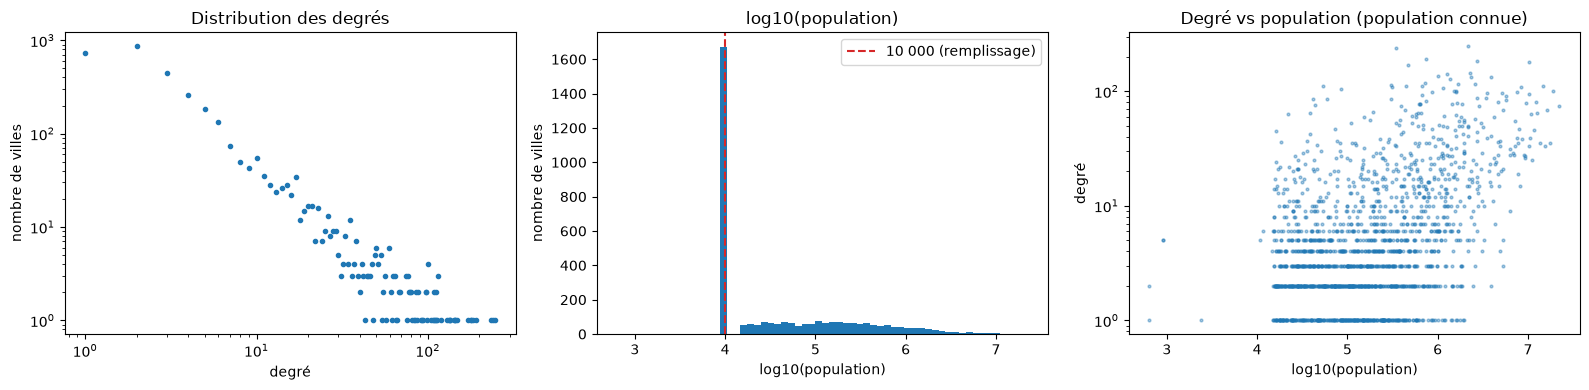

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution des degrés (log-log)
vc = deg.value_counts().sort_index()
axes[0].loglog(vc.index, vc.values, "o", ms=3)
axes[0].set(title="Distribution des degrés", xlabel="degré", ylabel="nombre de villes")

# Population : pic à 10 000 (valeur de remplissage)
axes[1].hist(np.log10(raw["population"]), bins=60)
axes[1].axvline(4, color="C3", ls="--", label="10 000 (remplissage)")
axes[1].set(title="log10(population)", xlabel="log10(population)", ylabel="nombre de villes")
axes[1].legend()

# Degré vs population (nœuds à population connue)
axes[2].scatter(np.log10(raw.loc[known, "population"]), deg[known], s=4, alpha=.4)
axes[2].set(yscale="log", title="Degré vs population (population connue)",
            xlabel="log10(population)", ylabel="degré")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_degree_population.png", dpi=120)
plt.show()

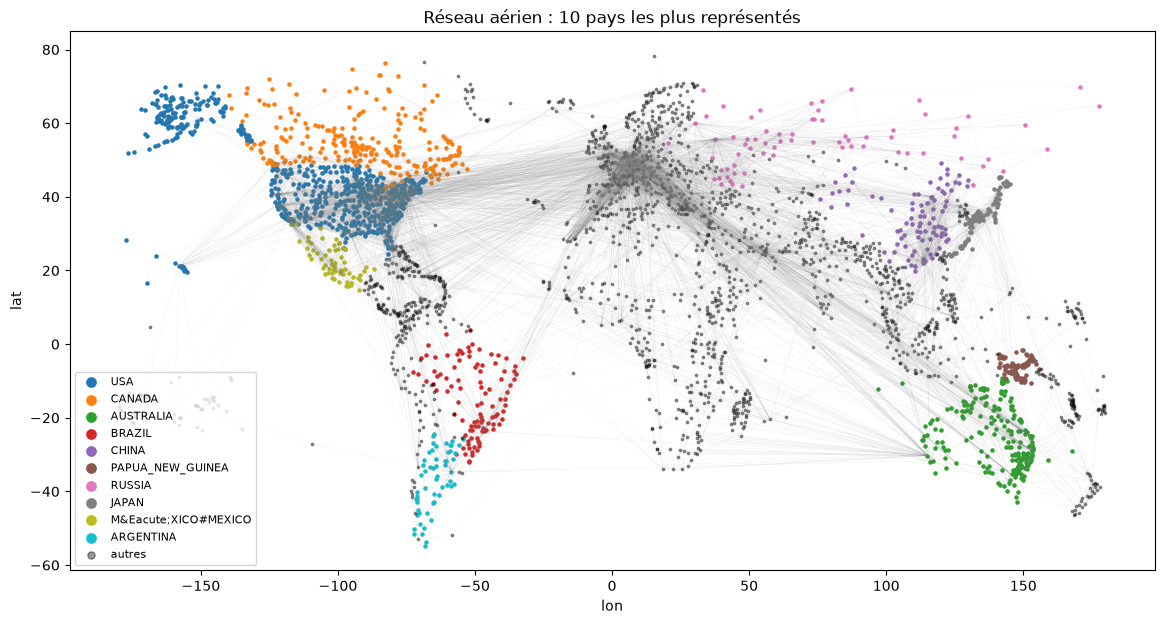

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))
edges = np.array(G.edges)
lon, lat = raw["lon"].values, raw["lat"].values
# Arêtes (sans celles qui traversent l'antiméridien, pour la lisibilité)
short = np.abs(lon[edges[:, 0]] - lon[edges[:, 1]]) < 180
for u, v in edges[short]:
    ax.plot([lon[u], lon[v]], [lat[u], lat[v]], color="grey", lw=.1, alpha=.3)
top = country_counts.index[:10]
for c in top:
    m = raw["country"] == c
    ax.scatter(lon[m], lat[m], s=5, label=c)
m = ~raw["country"].isin(top)
ax.scatter(lon[m], lat[m], s=3, color="black", alpha=.4, label="autres")
ax.set(title="Réseau aérien : 10 pays les plus représentés", xlabel="lon", ylabel="lat")
ax.legend(markerscale=3, fontsize=8, loc="lower left")
plt.savefig(FIG_DIR / "01_map.png", dpi=120)
plt.show()

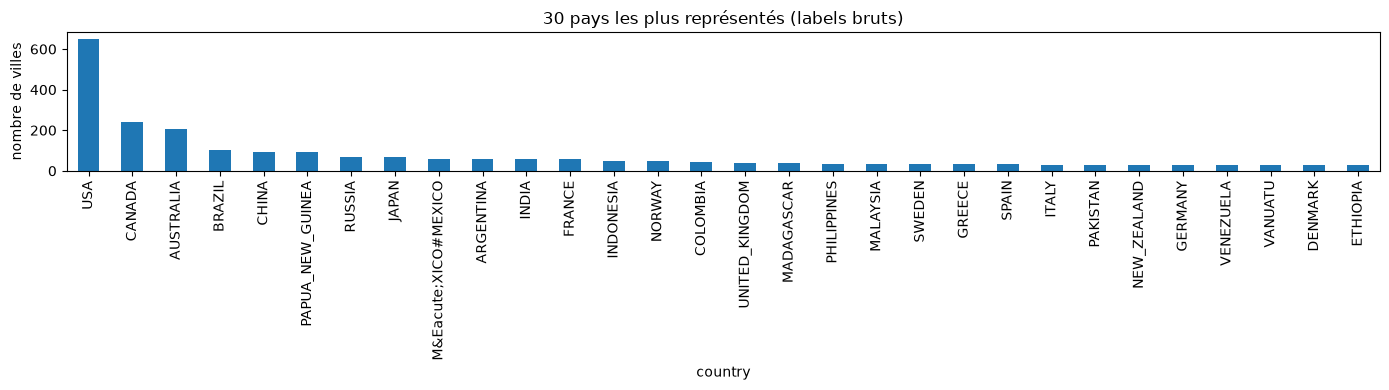

Noms bruités : ["CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC", 'CONGO,_REPUBLIC_OF_THE', 'HA&Iuml;TI#HAITI', 'M&Eacute;XICO#MEXICO', 'PER&Uacute;#PERU', 'SAINT-PIERRE_AND_MIQUELON#ST-PIERRE_AND_MIQUELON', 'SAINT_HELENA#ST_HELENA', 'SAINT_KITTS_AND_NEVIS#ST_KITTS_AND_NEVIS', 'SAINT_LUCIA#ST_LUCIA', 'SAINT_VINCENT_AND_THE_GRENADINES#ST_VINCENT_AND_THE_GRENADINES', 'VI&Ecirc;T_NAM#VIET_NAM,VIETNAM']


In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
country_counts.head(30).plot.bar(ax=ax)
ax.set(title="30 pays les plus représentés (labels bruts)", ylabel="nombre de villes")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_countries.png", dpi=120)
plt.show()

print("Noms bruités :", sorted(c for c in country_counts.index if any(s in c for s in "&#,")))

**Piège 1 — les coordonnées contiennent presque la réponse.** Un 1-NN sur (lat, lon), sans aucune arête,
avec 50 % des nœuds en test :

In [7]:
Xc = raw[["lat", "lon"]].values
tr, te = train_test_split(np.arange(N), test_size=.5, random_state=0)
knn1 = KNeighborsClassifier(1).fit(Xc[tr], raw["country"].values[tr])
print(f"1-NN sur coordonnées : accuracy = {knn1.score(Xc[te], raw['country'].values[te]):.3f}")

1-NN sur coordonnées : accuracy = 0.839


**Trois pièges**
1. Coordonnées quasi-oracles → tout évaluer en **scénario A (avec coords)** et **B (sans coords)**.
2. ≈ 50 % des populations valent 10 000 → nœuds gardés dans le graphe, mais **exclus de la loss et de l'évaluation T2**.
3. Labels pays bruités et déséquilibrés → nettoyage, classe `OTHER` pour les pays < 5 villes, **F1-macro** en plus de l'accuracy.

## 2. Nettoyage et préparation des données

### 2.1 Nettoyage des labels de pays
- Si le nom contient `#`, garder la partie après le `#`.
- Si le résultat contient une virgule, garder la première forme.
- Pays avec moins de 5 villes → `OTHER`.

 La règle de la virgule n'est appliquée qu'à la partie après le `#` (liste d'alias).
Appliquée partout, elle fusionnerait `CONGO,_REPUBLIC_OF_THE` et `CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC` en `CONGO`.

In [8]:
def clean_country(name: str) -> str:
    name = html.unescape(name).strip()
    if "#" in name:
        name = name.split("#", 1)[1].split(",", 1)[0]
    return name.strip()


def group_rare(countries, min_count=MIN_CITIES):
    counts = Counter(countries)
    return [c if counts[c] >= min_count else OTHER for c in countries]


for c in ["M&Eacute;XICO#MEXICO", "PER&Uacute;#PERU", "VI&Ecirc;T_NAM#VIET_NAM,VIETNAM",
          "CONGO,_REPUBLIC_OF_THE", "CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC"]:
    print(f"{c:40s} -> {clean_country(c)}")

M&Eacute;XICO#MEXICO                     -> MEXICO
PER&Uacute;#PERU                         -> PERU
VI&Ecirc;T_NAM#VIET_NAM,VIETNAM          -> VIET_NAM
CONGO,_REPUBLIC_OF_THE                   -> CONGO,_REPUBLIC_OF_THE
CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC     -> CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC


### 2.2 Cible de population
`y_pop = log10(population)` et `mask_pop = population != 10000`.

### 2.3 Features des nœuds

La population n'est jamais une feature pour T1, le pays jamais une feature pour T2.

In [9]:
def geo_features(lat, lon):
    """(cos lat·cos lon, cos lat·sin lon, sin lat) : pas de discontinuité à ±180°."""
    lat, lon = np.radians(lat), np.radians(lon)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=1)


def structural_features(G):
    n = G.number_of_nodes()
    deg = np.array([G.degree(i) for i in range(n)], dtype=float)
    pr, cl, cc = nx.pagerank(G), nx.clustering(G), nx.closeness_centrality(G)
    feats = np.stack([
        np.log1p(deg),
        np.log([pr[i] for i in range(n)]),   # PageRank très asymétrique -> log
        [cl[i] for i in range(n)],
        [cc[i] for i in range(n)],
    ], axis=1)
    # Standardisation transductive : les features de tous les nœuds sont visibles, pas les labels
    return (feats - feats.mean(0)) / feats.std(0)

### 2.4 Conversion en `torch_geometric.data.Data`

In [10]:
def build_data(G):
    n = G.number_of_nodes()
    attrs = [G.nodes[i] for i in range(n)]
    lat = np.array([a["lat"] for a in attrs], dtype=float)
    lon = np.array([a["lon"] for a in attrs], dtype=float)
    pop = np.array([a["population"] for a in attrs], dtype=np.int64)

    countries = group_rare([clean_country(a["country"]) for a in attrs])
    classes = sorted(set(countries) - {OTHER}) + [OTHER]
    class_idx = {c: i for i, c in enumerate(classes)}

    x_geo = torch.tensor(geo_features(lat, lon), dtype=torch.float)
    x_struct = torch.tensor(structural_features(G), dtype=torch.float)
    edge_index = to_undirected(torch.tensor(list(G.edges)).t(), num_nodes=n)

    data = Data(
        x=torch.cat([x_geo, x_struct], dim=1),   # scénario A
        x_geo=x_geo,
        x_struct=x_struct,                        # scénario B
        edge_index=edge_index,
        y_country=torch.tensor([class_idx[c] for c in countries]),
        y_pop=torch.tensor(np.log10(pop), dtype=torch.float),
        mask_pop=torch.tensor(pop != FILLER_POP),
        num_nodes=n,
    )
    # Métadonnées (jamais utilisées comme features)
    data.country_names = classes
    data.city_name = [a["city_name"] for a in attrs]
    return data


def features(data, scenario):
    return {"A": data.x, "B": data.x_struct}[scenario]


data = build_data(G)
torch.save(data, PROCESSED_DIR / "airports.pt")
NUM_CLASSES = len(data.country_names)

counts = torch.bincount(data.y_country)
print(data)
print(f"Classes pays : {NUM_CLASSES} (OTHER = {counts[-1].item()} villes, "
      f"plus grande classe = {counts.max().item()}, plus petite = {counts.min().item()})")
print(f"Homophilie des arêtes (labels nettoyés) : "
      f"{(data.y_country[data.edge_index[0]] == data.y_country[data.edge_index[1]]).float().mean():.3f}")
print(f"Nœuds avec population connue (mask_pop) : {int(data.mask_pop.sum())}")

Data(x=[3363, 7], edge_index=[2, 27094], x_geo=[3363, 3], x_struct=[3363, 4], y_country=[3363], y_pop=[3363], mask_pop=[3363], num_nodes=3363, country_names=[100], city_name=[3363])
Classes pays : 100 (OTHER = 203 villes, plus grande classe = 650, plus petite = 5)
Homophilie des arêtes (labels nettoyés) : 0.592
Nœuds avec population connue (mask_pop) : 1690


## 3. Protocole expérimental

- Scénarios : **A** (coords + structure) et **B** (structure seule).
- Taux de labels : 10 %, 30 %, 50 % pour l'entraînement ; val = 10 % ; test = le reste.
- T1 : tous les nœuds, découpage **stratifié par pays**. T2 : uniquement les nœuds de `mask_pop` (les autres restent dans le graphe).
- Cadre transductif : le graphe complet est toujours visible, seuls les labels sont cachés.
- 10 graines (0…9), résultats en moyenne ± écart-type, early stopping sur la validation (patience = 50).
- Hyperparamètres des GNN : Optuna sur la validation uniquement (plages ci-dessous, utilisées aux étapes suivantes).

In [11]:
TASKS = ("country", "pop")
SCENARIOS = ("A", "B")
LABEL_RATES = (0.1, 0.3, 0.5)
SEEDS = tuple(range(10))
VAL_RATE = 0.1
PATIENCE = 50

# Espace de recherche Optuna (pour les GNN, étapes suivantes)
SEARCH_SPACE = {
    "hidden": [32, 64, 128, 256],
    "num_layers": (1, 4),
    "dropout": (0.0, 0.6),
    "lr": (1e-4, 1e-2),          # échelle log
    "weight_decay": (0.0, 5e-4),
    "heads": [1, 2, 4, 8],       # GAT
}


def make_split(candidates, rate, seed, stratify=None):
    """train = rate, val = 10 %, test = le reste (en proportion de `candidates`)."""
    n = len(candidates)
    n_train, n_val = round(rate * n), round(VAL_RATE * n)

    def split(idx, strat, size):
        try:
            return train_test_split(idx, train_size=size, random_state=seed, stratify=strat)
        except ValueError:  # stratification impossible -> aléatoire
            return train_test_split(idx, train_size=size, random_state=seed)

    train, rest = split(candidates, stratify, n_train)
    rest_strat = None if stratify is None else stratify[np.searchsorted(candidates, rest)]
    val, test = split(rest, rest_strat, n_val)
    return {k: torch.from_numpy(np.sort(v)) for k, v in (("train", train), ("val", val), ("test", test))}


all_nodes = np.arange(data.num_nodes)
pop_nodes = np.flatnonzero(data.mask_pop.numpy())
splits = {}
for rate in LABEL_RATES:
    for seed in SEEDS:
        splits[("country", rate, seed)] = make_split(all_nodes, rate, seed, stratify=data.y_country.numpy())
        splits[("pop", rate, seed)] = make_split(pop_nodes, rate, seed)
torch.save(splits, PROCESSED_DIR / "splits.pt")

pd.DataFrame([
    {"tâche": t, "taux": r, **{k: len(v) for k, v in splits[(t, r, 0)].items()},
     "classes vues en train": len(set(data.y_country[splits[(t, r, 0)]["train"]].tolist())) if t == "country" else "—"}
    for t in TASKS for r in LABEL_RATES
])

,tâche,taux,train,val,test,classes vues en train
0,country,0.1,336,336,2691,93
1,country,0.3,1009,336,2018,100
2,country,0.5,1682,336,1345,100
3,pop,0.1,169,169,1352,—
4,pop,0.3,507,169,1014,—
5,pop,0.5,845,169,676,—


## 4. Baselines



Les baselines qui n'utilisent pas les features (majoritaire, Label Propagation, Node2Vec) donnent le même
score dans les deux scénarios : elles sont calculées une fois et reportées en A et en B.
Leurs quelques hyperparamètres (k, α, C…) sont choisis sur la validation par petite grille.

Métriques : T1 → accuracy et F1-macro ; T2 → MAE, RMSE et R² sur `log10(population)`.

In [12]:
def evaluate(task, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if task == "country":
        return {"acc": accuracy_score(y_true, y_pred),
                "f1_macro": f1_score(y_true, y_pred, average="macro")}
    return {"mae": mean_absolute_error(y_true, y_pred),
            "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
            "r2": r2_score(y_true, y_pred)}


def val_score(task, y_true, y_pred):
    """Critère de sélection sur la validation (plus grand = meilleur)."""
    m = evaluate(task, y_true, y_pred)
    return m["acc"] if task == "country" else -m["rmse"]


def target(task):
    return data.y_country if task == "country" else data.y_pop


def select_on_val(task, split, candidates):
    """candidates : dict nom -> prédictions sur tous les nœuds. Retourne les métriques test du meilleur."""
    y = target(task).numpy()
    va, te = split["val"].numpy(), split["test"].numpy()
    best = max(candidates, key=lambda k: val_score(task, y[va], candidates[k][va]))
    return evaluate(task, y[te], candidates[best][te]), best

### 4.1 Classe majoritaire / moyenne

In [13]:
def run_majority(task, split):
    y = target(task).numpy()
    tr = split["train"].numpy()
    value = np.bincount(y[tr]).argmax() if task == "country" else y[tr].mean()
    te = split["test"].numpy()
    return evaluate(task, y[te], np.full(len(te), value)), "-"

### 4.2 MLP (early stopping sur la validation, patience = 50)

In [14]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden, out_dim))

    def forward(self, x):
        return self.net(x)


def run_mlp(task, split, scenario, seed, hidden=64, dropout=0.3, lr=1e-2, wd=5e-4, max_epochs=2000):
    torch.manual_seed(seed)
    x, y = features(data, scenario), target(task)
    tr, va, te = split["train"], split["val"], split["test"]
    clf = task == "country"
    model = MLP(x.size(1), hidden, NUM_CLASSES if clf else 1, dropout)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    def predict():
        model.eval()
        with torch.no_grad():
            out = model(x)
        return (out.argmax(1) if clf else out.squeeze(1)).numpy()

    best, best_pred, wait = -np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()
        out = model(x[tr])
        loss = F.cross_entropy(out, y[tr]) if clf else F.mse_loss(out.squeeze(1), y[tr])
        loss.backward()
        opt.step()

        pred = predict()
        score = val_score(task, y[va].numpy(), pred[va])
        if score > best:
            best, best_pred, wait = score, pred, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    return evaluate(task, y[te].numpy(), best_pred[te]), f"epochs={epoch + 1}"

### 4.3 k-NN sur coordonnées (scénario A uniquement)

In [15]:
def run_knn(task, split):
    x = data.x_geo.numpy()   # distance euclidienne en (x, y, z) = monotone en la distance orthodromique
    y = target(task).numpy()
    tr = split["train"].numpy()
    Model = KNeighborsClassifier if task == "country" else KNeighborsRegressor
    candidates = {}
    for k in (1, 3, 5, 10, 20):
        for w in ("uniform", "distance"):
            if k <= len(tr):
                candidates[f"k={k},{w}"] = Model(k, weights=w).fit(x[tr], y[tr]).predict(x)
    return select_on_val(task, split, candidates)

### 4.4 Label Propagation (graphe seul, T1 uniquement)

In [16]:
def run_label_propagation(split):
    y = data.y_country
    mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    mask[split["train"]] = True
    candidates = {}
    for alpha in (0.5, 0.7, 0.9, 0.99):
        out = LabelPropagation(num_layers=50, alpha=alpha)(y, data.edge_index, mask=mask)
        pred = out.argmax(1).numpy()
        pred[split["train"].numpy()] = y[split["train"]].numpy()
        candidates[f"alpha={alpha}"] = pred
    return select_on_val("country", split, candidates)

### 4.5 Node2Vec + régression logistique / linéaire

Les embeddings sont non supervisés (ils ne dépendent pas des labels) : un embedding par graine, mis en cache.
Marches uniformes (p = q = 1, équivalent DeepWalk) : l'échantillonneur de `pyg_lib` ne gère pas encore les marches biaisées.

In [17]:
def node2vec_embedding(seed, dim=64, epochs=10):
    path = PROCESSED_DIR / f"node2vec_seed{seed}.pt"
    if path.exists():
        return torch.load(path)
    torch.manual_seed(seed)
    model = Node2Vec(data.edge_index, embedding_dim=dim, walk_length=20, context_size=10,
                     walks_per_node=10, num_negative_samples=1, p=1.0, q=1.0,
                     num_nodes=data.num_nodes, sparse=True)
    loader = model.loader(batch_size=128, shuffle=True)
    opt = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)
    model.train()
    for _ in range(epochs):
        for pos_rw, neg_rw in loader:
            opt.zero_grad()
            loss = model.loss(pos_rw, neg_rw)
            loss.backward()
            opt.step()
    emb = model.embedding.weight.detach().clone()
    torch.save(emb, path)
    return emb


def run_node2vec(task, split, seed):
    z = StandardScaler().fit_transform(node2vec_embedding(seed).numpy())
    y = target(task).numpy()
    tr = split["train"].numpy()
    candidates = {}
    for c in (0.01, 0.1, 1.0, 10.0):
        if task == "country":
            m = LogisticRegression(C=c, max_iter=2000).fit(z[tr], y[tr])
        else:
            m = Ridge(alpha=1 / c).fit(z[tr], y[tr])
        candidates[f"C={c}"] = m.predict(z)
    return select_on_val(task, split, candidates)


t0 = time.time()
for s in SEEDS:
    node2vec_embedding(s)
print(f"Embeddings Node2Vec prêts ({time.time() - t0:.0f} s)")

Embeddings Node2Vec prêts (0 s)


### 4.6 Lancement de toutes les baselines

In [18]:
rows = []

def record(task, scenarios, model, rate, seed, result):
    metrics, chosen = result
    for sc in scenarios:
        rows.append({"task": task, "scenario": sc, "model": model, "rate": rate,
                     "seed": seed, "selected": chosen, **metrics})

t0 = time.time()
for task in TASKS:
    for rate in LABEL_RATES:
        for seed in SEEDS:
            split = splits[(task, rate, seed)]
            record(task, SCENARIOS, "Majoritaire/Moyenne", rate, seed, run_majority(task, split))
            for sc in SCENARIOS:
                record(task, [sc], "MLP", rate, seed, run_mlp(task, split, sc, seed))
            record(task, ["A"], "k-NN (coords)", rate, seed, run_knn(task, split))
            if task == "country":
                record(task, SCENARIOS, "Label Propagation", rate, seed, run_label_propagation(split))
            record(task, SCENARIOS, "Node2Vec + " + ("LogReg" if task == "country" else "Ridge"),
                   rate, seed, run_node2vec(task, split, seed))
    print(f"{task} terminé ({time.time() - t0:.0f} s)")

raw_results = pd.DataFrame(rows)
raw_results.to_csv(RESULTS_DIR / "baselines_raw.csv", index=False)
raw_results.head()

country terminé (272 s)


pop terminé (367 s)


,task,scenario,model,rate,seed,selected,acc,f1_macro,mae,rmse,r2
0,country,A,Majoritaire/Moyenne,0.1,0,-,0.193237,0.003239,NaN,NaN,NaN
1,country,B,Majoritaire/Moyenne,0.1,0,-,0.193237,0.003239,NaN,NaN,NaN
2,country,A,MLP,0.1,0,epochs=167,0.541434,0.250076,NaN,NaN,NaN
3,country,B,MLP,0.1,0,epochs=54,0.184318,0.005187,NaN,NaN,NaN
4,country,A,k-NN (coords),0.1,0,"k=1,uniform",0.777406,0.617309,NaN,NaN,NaN


### 4.7 Résultats (moyenne ± écart-type sur 10 graines, ensemble de test)

In [19]:
MODEL_ORDER = ["Majoritaire/Moyenne", "MLP", "k-NN (coords)", "Label Propagation",
               "Node2Vec + LogReg", "Node2Vec + Ridge"]


def summary_table(task, metric):
    df = raw_results[raw_results.task == task]
    g = df.groupby(["scenario", "model", "rate"])[metric].agg(["mean", "std"])
    fmt = (g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)).unstack("rate")
    fmt.columns = [f"{int(r * 100)} %" for r in fmt.columns]
    order = [m for m in MODEL_ORDER if m in fmt.index.get_level_values("model")]
    return fmt.reindex(pd.MultiIndex.from_product([SCENARIOS, order])).dropna(how="all")


summary = []
for task, metrics in (("country", ["acc", "f1_macro"]), ("pop", ["mae", "rmse", "r2"])):
    for metric in metrics:
        t = summary_table(task, metric)
        summary.append(t.assign(task=task, metric=metric))
        print(f"\n=== T{1 if task == 'country' else 2} ({task}) — {metric} ===")
        display(t)
pd.concat(summary).to_csv(RESULTS_DIR / "baselines_summary.csv")


=== T1 (country) — acc ===


10 %           30 %           50 %
A Majoritaire/Moyenne  0.193 ± 0.000  0.193 ± 0.000  0.193 ± 0.000
  MLP                  0.562 ± 0.020  0.738 ± 0.010  0.766 ± 0.011
  k-NN (coords)        0.780 ± 0.007  0.848 ± 0.006  0.865 ± 0.008
  Label Propagation    0.821 ± 0.014  0.868 ± 0.005  0.885 ± 0.006
  Node2Vec + LogReg    0.357 ± 0.010  0.455 ± 0.008  0.489 ± 0.014
B Majoritaire/Moyenne  0.193 ± 0.000  0.193 ± 0.000  0.193 ± 0.000
  MLP                  0.203 ± 0.014  0.224 ± 0.031  0.260 ± 0.026
  Label Propagation    0.821 ± 0.014  0.868 ± 0.005  0.885 ± 0.006
  Node2Vec + LogReg    0.357 ± 0.010  0.455 ± 0.008  0.489 ± 0.014


=== T1 (country) — f1_macro ===


10 %           30 %           50 %
A Majoritaire/Moyenne  0.003 ± 0.000  0.003 ± 0.000  0.003 ± 0.000
  MLP                  0.273 ± 0.024  0.471 ± 0.019  0.495 ± 0.020
  k-NN (coords)        0.616 ± 0.020  0.730 ± 0.015  0.762 ± 0.023
  Label Propagation    0.689 ± 0.028  0.779 ± 0.016  0.802 ± 0.013
  Node2Vec + LogReg    0.071 ± 0.011  0.147 ± 0.006  0.193 ± 0.013
B Majoritaire/Moyenne  0.003 ± 0.000  0.003 ± 0.000  0.003 ± 0.000
  MLP                  0.020 ± 0.011  0.021 ± 0.016  0.042 ± 0.019
  Label Propagation    0.689 ± 0.028  0.779 ± 0.016  0.802 ± 0.013
  Node2Vec + LogReg    0.071 ± 0.011  0.147 ± 0.006  0.193 ± 0.013


=== T2 (pop) — mae ===


10 %           30 %           50 %
A Majoritaire/Moyenne  0.557 ± 0.005  0.554 ± 0.009  0.562 ± 0.012
  MLP                  0.445 ± 0.019  0.414 ± 0.006  0.416 ± 0.013
  k-NN (coords)        0.503 ± 0.011  0.474 ± 0.013  0.467 ± 0.014
  Node2Vec + Ridge     0.471 ± 0.012  0.454 ± 0.007  0.454 ± 0.008
B Majoritaire/Moyenne  0.557 ± 0.005  0.554 ± 0.009  0.562 ± 0.012
  MLP                  0.494 ± 0.014  0.481 ± 0.007  0.492 ± 0.014
  Node2Vec + Ridge     0.471 ± 0.012  0.454 ± 0.007  0.454 ± 0.008


=== T2 (pop) — rmse ===


10 %           30 %           50 %
A Majoritaire/Moyenne  0.682 ± 0.005  0.678 ± 0.011  0.686 ± 0.015
  MLP                  0.566 ± 0.025  0.522 ± 0.009  0.522 ± 0.016
  k-NN (coords)        0.628 ± 0.008  0.599 ± 0.013  0.593 ± 0.018
  Node2Vec + Ridge     0.584 ± 0.014  0.567 ± 0.008  0.564 ± 0.010
B Majoritaire/Moyenne  0.682 ± 0.005  0.678 ± 0.011  0.686 ± 0.015
  MLP                  0.611 ± 0.019  0.591 ± 0.007  0.604 ± 0.019
  Node2Vec + Ridge     0.584 ± 0.014  0.567 ± 0.008  0.564 ± 0.010


=== T2 (pop) — r2 ===


10 %            30 %            50 %
A Majoritaire/Moyenne  -0.005 ± 0.009  -0.002 ± 0.004  -0.003 ± 0.004
  MLP                   0.304 ± 0.069   0.406 ± 0.022   0.418 ± 0.039
  k-NN (coords)         0.148 ± 0.018   0.217 ± 0.023   0.250 ± 0.030
  Node2Vec + Ridge      0.260 ± 0.044   0.300 ± 0.020   0.320 ± 0.044
B Majoritaire/Moyenne  -0.005 ± 0.009  -0.002 ± 0.004  -0.003 ± 0.004
  MLP                   0.191 ± 0.044   0.238 ± 0.012   0.220 ± 0.047
  Node2Vec + Ridge      0.260 ± 0.044   0.300 ± 0.020   0.320 ± 0.044

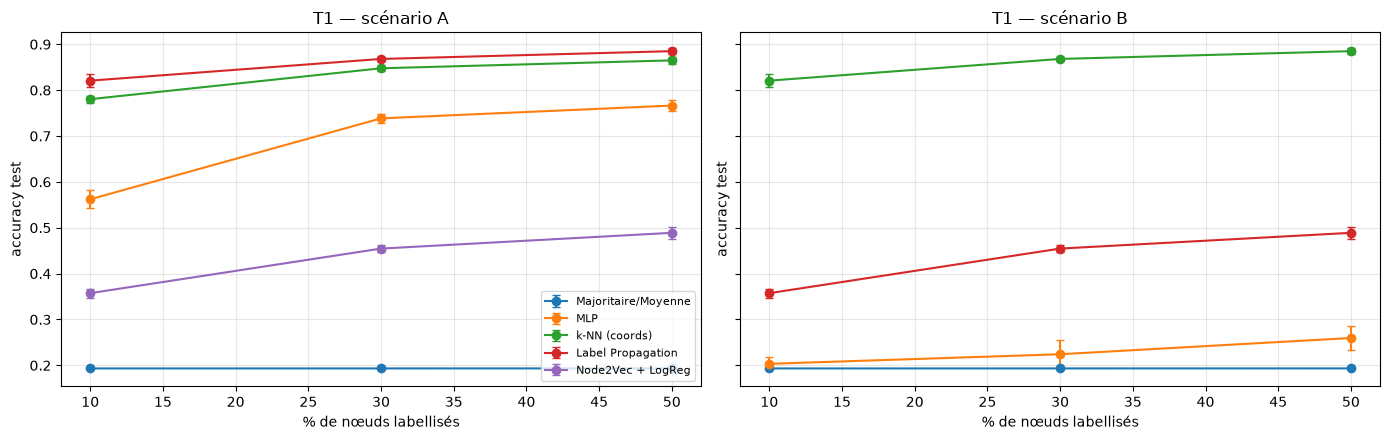

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
df = raw_results[raw_results.task == "country"]
for ax, sc in zip(axes, SCENARIOS):
    g = df[df.scenario == sc].groupby(["model", "rate"])["acc"].agg(["mean", "std"]).reset_index()
    for model in [m for m in MODEL_ORDER if m in set(g.model)]:
        d = g[g.model == model]
        ax.errorbar(d.rate * 100, d["mean"], yerr=d["std"], marker="o", capsize=3, label=model)
    ax.set(title=f"T1 — scénario {sc}", xlabel="% de nœuds labellisés", ylabel="accuracy test")
    ax.grid(alpha=.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_baselines_t1.png", dpi=120)
plt.show()

**À vérifier dans les tableaux :**
- Scénario A : le k-NN sur coordonnées est la baseline forte ; un GNN devra la battre pour être utile.
- Scénario B : le MLP (features structurelles seules) devrait s'effondrer, tandis que Label Propagation et Node2Vec devraient bien résister.

## 5. Discussion des résultats

*Chiffres : moyenne sur 10 graines, ensemble de test (voir tableaux du §4.7).*

### T1 — Prédiction du pays

| Accuracy (F1-macro) | 10 % | 30 % | 50 % |
|---|---|---|---|
| Majoritaire | 0.193 (0.003) | 0.193 (0.003) | 0.193 (0.003) |
| MLP — A | 0.562 (0.273) | 0.738 (0.471) | 0.766 (0.495) |
| MLP — B | 0.203 (0.020) | 0.224 (0.021) | 0.260 (0.042) |
| k-NN coords — A | 0.780 (0.616) | 0.848 (0.730) | 0.865 (0.762) |
| **Label Propagation** | **0.821 (0.689)** | **0.868 (0.779)** | **0.885 (0.802)** |
| Node2Vec + LogReg | 0.357 (0.071) | 0.455 (0.147) | 0.489 (0.193) |

**1. Le graphe à lui seul suffit presque.** La Label Propagation, qui n'utilise *aucune* feature, est la meilleure baseline à tous les taux de labels, devant le k-NN sur coordonnées. C'est cohérent avec la forte homophilie des arêtes (0.59 après nettoyage) : la majorité des lignes aériennes relient deux villes du même pays (vols intérieurs). L'écart avec le k-NN est le plus grand quand les labels sont rares (+4 points à 10 %) : la propagation exploite la structure des nœuds non labellisés, ce que le k-NN ne peut pas faire.

**2. Le piège 1 est confirmé.** Le k-NN sur coordonnées atteint 0.865 à 50 % de labels, en accord avec l'estimation de ≈ 85 %. Dans le scénario A, un GNN qui utilise les coordonnées doit donc battre **0.885 (Label Propagation)**, et pas seulement 0.865, pour justifier sa complexité.

**3. Le scénario B isole bien l'apport du graphe.** Sans coordonnées, le MLP s'effondre (0.26, à peine au-dessus de la classe majoritaire à 0.19) : degré, PageRank, clustering et centralité décrivent le *rôle* d'une ville dans le réseau (hub, ville isolée…), pas *où* elle se trouve. Un GNN en scénario B ne peut donc réussir que par le passage de messages, ce qui en fait le cadre le plus informatif pour la suite.

**4. Le MLP en A reste loin du k-NN** (0.766 contre 0.865), alors qu'il dispose des mêmes coordonnées. Un MLP à 2 couches apprend mal les frontières très irrégulières entre 100 pays dans l'espace (x, y, z) ; le k-NN, non paramétrique, les capture directement.

**5. Node2Vec déçoit, contrairement à ce qui était attendu.** Les embeddings capturent la proximité dans le réseau, mais une régression logistique sur 100 classes déséquilibrées, avec seulement 64 dimensions, 10 epochs et des marches uniformes (p = q = 1, DeepWalk), reste loin de la Label Propagation. Pistes : plus d'epochs, dimension 128, des marches biaisées vers le voisinage local (q > 1, plus « BFS ») pour mieux refléter l'homophilie, ou un k-NN sur les embeddings plutôt qu'un classifieur linéaire.

**6. Le F1-macro révèle le déséquilibre (piège 3).** L'écart accuracy / F1-macro est important partout (0.885 contre 0.802 pour la Label Propagation, 0.489 contre 0.193 pour Node2Vec) : les petits pays sont bien moins bien classés que les USA, le Canada ou l'Australie. La classe majoritaire obtient 0.193 d'accuracy mais 0.003 de F1-macro, ce qui montre pourquoi l'accuracy seule serait trompeuse.

### T2 — Prédiction de log10(population)

| R² (RMSE) | 10 % | 30 % | 50 % |
|---|---|---|---|
| Moyenne | −0.005 (0.682) | −0.002 (0.678) | −0.003 (0.686) |
| **MLP — A** | **0.304 (0.566)** | **0.406 (0.522)** | **0.418 (0.522)** |
| MLP — B | 0.191 (0.611) | 0.238 (0.591) | 0.220 (0.604) |
| k-NN coords — A | 0.148 (0.628) | 0.217 (0.599) | 0.250 (0.593) |
| Node2Vec + Ridge | 0.260 (0.584) | 0.300 (0.567) | 0.320 (0.564) |

**7. T2 est une tâche bien plus difficile.** Le meilleur R² est ≈ 0.42 : environ 60 % de la variance de la population n'est expliquée par aucune baseline. Une erreur RMSE de 0.52 en log10 correspond à un facteur ≈ 3,3 sur la population.

**8. Ici, c'est la structure qui compte, pas la géographie.** Contrairement à T1, le k-NN sur coordonnées est la *plus faible* des baselines informatives : deux villes voisines n'ont pas une population similaire. En revanche, le degré est un bon indicateur (corrélation 0.36) : une grande ville a un aéroport avec beaucoup de lignes. Le MLP en scénario B (structure seule, R² ≈ 0.22) capte cette information ; ajouter les coordonnées (scénario A) le fait monter à 0.42, sans doute parce que la région module le lien entre degré et population (un hub européen et une ville isolée du Grand Nord canadien n'ont pas le même profil).

**9. Node2Vec fait mieux que le MLP-B** (0.32 contre 0.22) : sa position dans le réseau (proximité des hubs, communautés) apporte plus que les 4 features structurelles.

**10. Les résultats saturent vite.** Entre 30 % et 50 % de labels, les gains sont faibles, voire nuls (MLP-B), et la variance entre graines devient comparable à l'écart. Attention toutefois : les découpages T2 ne portent que sur les 1 690 villes à population connue, donc 10 % ne représente que 169 nœuds d'entraînement.

### Conclusions pour la suite (GNN)

- **Scénario A, T1** : l'objectif est de battre 0.885 / F1 0.802 (Label Propagation), pas seulement le k-NN. Un GNN qui combine coordonnées et passage de messages devrait pouvoir cumuler les deux signaux.
- **Scénario B, T1** : c'est là qu'un GNN a le plus à prouver. Il part des mêmes features que le MLP (0.26) et doit se rapprocher de la Label Propagation. Des architectures qui propagent bien les labels, comme APPNP ou un GCN combiné à de la Label Propagation (C&S), sont de bons candidats.
- **T2** : la barre est R² ≈ 0.42. L'agrégation des voisins (par exemple le degré ou la population connue des voisins) pourrait aider, puisque les hubs sont reliés entre eux.
- **Limites des baselines** : les hyperparamètres sont choisis sur une petite grille et le MLP n'est pas passé par Optuna. Il faudra appliquer la même recherche Optuna aux baselines et aux GNN pour que la comparaison soit équitable.